# Reinforcement learning fundamentals

Reinforcement Learning (RL) is a branch of machine learning focused on training an agent to make sequential decisions by interacting with an environment and receiving feedback in the form of rewards. Unlike supervised learning, where labeled data guides the model, or unsupervised learning, which finds hidden structure in data, RL emphasizes trial-and-error learning. This part begins by introducing the core components of RL, including agents, environments, states, actions, rewards, policies, and value functions, which together define how an agent perceives and influences its surroundings. We also formalize the problem using the Markov Decision Process (MDP) framework, which provides a mathematical basis for decision-making under uncertainty.

A key challenge in RL is the exploration vs. exploitation trade-off: deciding when to try new actions to discover better strategies and when to stick to the best-known actions. We then explore value-based methods, where the agent estimates long-term rewards through state and action value functions, and learns optimal decision-making using the Bellman equations. The material covers fundamental algorithms such as Dynamic Programming, Q-Learning, and SARSA, focusing on their logic and implementation in tabular settings without deep learning. By the end, learners will understand the essential theory and tools to build simple RL agents capable of solving small-scale decision problems.

### Core concepts

At the heart of Reinforcement Learning (RL) lies the interaction between an agent and an environment. The agent observes the state of the environment, chooses an action, and receives a reward as feedback. This loop continues over a series of time steps, allowing the agent to learn a policy—a mapping from states to actions—that maximizes cumulative reward. In many cases, we also use value functions to estimate how good it is to be in a certain state (or take a certain action), helping the agent make informed decisions.

Here’s a breakdown of the main components:

- Agent – The learner/decision-maker.
- Environment – Everything the agent interacts with.
- State (SSS) – The current situation of the agent (can be fully or partially observable).
- Action (AAA) – A choice available to the agent in a given state.
- Reward (RRR) – A numerical signal indicating the immediate benefit of an action.
- Policy (π\piπ) – The strategy that defines the agent’s actions in different states.
- Value Functions – Predictions of long-term rewards:
    - State-value function V(s)V(s)V(s) – Expected return from a state.
    - Action-value function Q(s,a)Q(s,a)Q(s,a) – Expected return from a specific action in a state.


In [3]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 4.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gymnasium]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False)

state, info = env.reset()

for step in range(5):

    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"State: {state}, Action: {action}, Reward: {reward}, Next State: {next_state}")

    state = next_state

    if terminated or truncated:
        break

env.close()

State: 0, Action: 3, Reward: 0, Next State: 0
State: 0, Action: 3, Reward: 0, Next State: 0
State: 0, Action: 1, Reward: 0, Next State: 4
State: 4, Action: 1, Reward: 0, Next State: 8
State: 8, Action: 3, Reward: 0, Next State: 4


What’s happening here?

- State: Agent’s position on the grid (in FrozenLake).
- Action: Move up, down, left, or right.
- Reward: 0 for normal moves, 1 if the goal is reached.
- Policy: Here, we use random actions (no learning yet).

This simple loop captures the essence of RL: the agent interacts with the environment, collects rewards, and will eventually learn to improve its actions based on experience.

### Markov Decision Process (MDP)

To formally describe a reinforcement learning problem, we often use a Markov Decision Process (MDP). An MDP provides a mathematical framework for modeling decision-making in situations where outcomes are partly random and partly under the control of an agent.

The key assumption in an MDP is the Markov property:

The future state depends only on the current state and action, not on the sequence of past states.

In [11]:
import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False)

state, info = env.reset()

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

# Access the raw MDP transition dictionary
P = env.unwrapped.P

print("Transitions from state 0 with action 'Right':")
for prob, next_state, reward, done in P[0][2]:
    print(f"Next State: {next_state}, Probability: {prob}, Reward: {reward}, Done: {done}")

env.close()

Number of states: 16
Number of actions: 4
Transitions from state 0 with action 'Right':
Next State: 1, Probability: 1.0, Reward: 0, Done: False


What’s happening here?

P[0][2] shows all possible outcomes if the agent is in state 0 and takes action 2 (“right”).
Each entry has a probability, the next state, the reward, and whether the episode ends.
This illustrates P(s' | s, a) and R(s, a) in action.

### Exploration vs Exploitation

A central challenge in reinforcement learning is the exploration–exploitation trade-off.

Exploration means trying out new actions to discover potentially better rewards.
Exploitation means choosing the best-known action so far to maximize immediate gains.
Too much exploration wastes time on suboptimal actions, while too much exploitation risks missing better strategies. The art of RL lies in balancing these two.

Several strategies help manage this balance:

- ε-greedy policy – Most of the time (with probability 1−ε1-\varepsilon1−ε), the agent exploits the best-known action, but with probability ε\varepsilonε, it explores a random action.
- Decay schedules – Gradually reduce ε over time so the agent explores early and exploits later.
- Softmax action selection – Choose actions probabilistically based on their estimated value.
- Upper Confidence Bound (UCB) – Select actions based on both estimated reward and uncertainty.

Example: ε-greedy Action Selection

In [15]:
import numpy as np

def epsilon_greedy(Q_values, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(len(Q_values))  # Explore
    else:
        return np.argmax(Q_values)  # Exploit

# Just an example, random values for state
Q_values = [1.2, 0.5, 0.8, 1.0]

for epsilon in [0.3, 0.1]:
    action = epsilon_greedy(Q_values, epsilon)
    print(f"Epsilon={epsilon}, Selected Action={action}")

Epsilon=0.3, Selected Action=0
Epsilon=0.1, Selected Action=0


# Value based methods
In value-based reinforcement learning, the agent learns to estimate how good it is to be in a given state (state-value function, V(s)) or how good it is to take a certain action in a given state (action-value function, Q(s,a)). Once these values are learned, the agent can select actions that maximize expected returns.

The two main approaches are:

- State-value methods – Learn V(s) and derive a policy from it.
- Action-value methods – Learn Q(s,a) directly, making it easier to choose optimal actions without knowing the environment’s model.
The Bellman equation lies at the heart of these methods:

Example: Tabular Q-Learning Q-Learning is an off-policy value-based algorithm. It updates Q-values using the Bellman optimality equation:

In [4]:
import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=False)
Q = np.zeros((env.observation_space.n, env.action_space.n))

# Hyperparameters
alpha = 0.1
gamma = 0.99
epsilon = 0.2
episodes = 500

def epsilon_greedy(Q_values, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(len(Q_values))
    return np.argmax(Q_values)

for _ in range(episodes):
    state, info = env.reset()
    done = False

    while not done:
        action = epsilon_greedy(Q[state], epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-learning update
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state

print("Learned Q-table:")
print(Q)

Learned Q-table:
[[0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.1 0. ]
 [0.  0.  0.  0. ]]


## Fundamental Algorithms
Traditional reinforcement learning algorithms learn directly from interactions with the environment, storing values in tables rather than using neural networks. The most important ones include:

1. Q-Learning (Off-Policy)

Learns the optimal action-value function regardless of the agent’s current policy.
Uses the max over next-state actions in the update.
Good for learning from any experience, not just the one generated by the current policy.
Update rule:

2. SARSA (On-Policy)
- Learns the action-value function for the current policy.
- Updates Q-values using the action actually taken in the next step.
- Slightly safer than Q-Learning in environments with high risk.
Update rule:

3. Monte Carlo Control
- Learns from complete episodes of experience.
- Updates Q-values based on actual returns without using a bootstrapped estimate.
- Works well in episodic tasks but is less efficient in continuous tasks.

Example: Q-Learning vs SARSA vs Monte Carlo Control

In [15]:
import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=False)
alpha, gamma, epsilon = 0.1, 0.99, 0.2
episodes = 500

def epsilon_greedy(Q_values, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(len(Q_values))
    return np.argmax(Q_values)

def run_q_learning():
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    for episode in range(episodes):
        state, info = env.reset()
        done = False

        # Decay epsilon
        epsilon_decay = max(0.01, 1 - episode / episodes)

        while not done:
            action = epsilon_greedy(Q[state], epsilon_decay)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )
            state = next_state

    return Q

def run_sarsa():
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    for _ in range(episodes):
        state, info = env.reset()
        action = epsilon_greedy(Q[state], epsilon)
        done = False

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            if not done:
                next_action = epsilon_greedy(Q[next_state], epsilon)
                target = reward + gamma * Q[next_state, next_action]
            else:
                next_action = None
                target = reward

            Q[state, action] += alpha * (target - Q[state, action])
            state = next_state
            action = next_action

    return Q

def run_monte_carlo():
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    returns = {
        (s, a): []
        for s in range(env.observation_space.n)
        for a in range(env.action_space.n)
    }

    for _ in range(episodes):
        state, info = env.reset()
        episode = []
        done = False

        while not done:
            action = epsilon_greedy(Q[state], epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            episode.append((state, action, reward))
            state = next_state

        G = 0
        visited = set()

        for state, action, reward in reversed(episode):
            G = gamma * G + reward

            if (state, action) not in visited:
                visited.add((state, action))
                returns[(state, action)].append(G)
                Q[state, action] = np.mean(returns[(state, action)])

    return Q

successes = 0

for episode in range(episodes):
    state, info = env.reset()
    done = False

    while not done:
        action = epsilon_greedy(Q[state], epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        if reward == 1:
            successes += 1

        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state

print("Times reached goal:", successes)


Q_q_learning = run_q_learning()
Q_sarsa = run_sarsa()
Q_mc = run_monte_carlo()

print("Q-Learning Q-table:\n", Q_q_learning)
print("SARSA Q-table:\n", Q_sarsa)
print("Monte Carlo Q-table:\n", Q_mc)

Times reached goal: 380
Q-Learning Q-table:
 [[8.77220834e-01 5.35792782e-01 9.50989098e-01 8.56105219e-01]
 [6.83770608e-01 0.00000000e+00 9.60595775e-01 7.82037335e-01]
 [7.21098903e-01 9.70298947e-01 4.85913817e-01 8.85316192e-01]
 [7.73866357e-01 0.00000000e+00 1.19525056e-01 5.15707137e-02]
 [9.29262526e-03 9.97440792e-03 0.00000000e+00 7.79392624e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 9.80099991e-01 0.00000000e+00 8.22143536e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.08723825e-05 0.00000000e+00 1.83211494e-01 4.35798130e-02]
 [2.75308065e-02 7.71277015e-02 8.87048622e-01 0.00000000e+00]
 [6.53253080e-01 9.89999999e-01 0.00000000e+00 8.20465456e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 8.63557155e-02 8.77451581e-01 1.91428509e-01]
 [6.72349833e-01 9.34956467e-01 1.00000000e+00 8.39534259e-01]
 [0.000000

### Exercise

**Cell 1 — Imports and Environment**

In [18]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("CliffWalking-v1")

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 48
Number of actions: 4


Explanation:
CliffWalking is a gridworld where:

- Start = bottom-left
- Goal = bottom-right
- Cliff = bottom row in between → very large negative reward if you fall

This environment is perfect for comparing Q-learning vs SARSA.

**Cell 2 — Helper Functions**

In [22]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])
    return np.argmax(Q[state])

def moving_average(x, window=50):
    if len(x) < window:
        return np.array(x)
    return np.convolve(x, np.ones(window) / window, mode="valid")

def derive_policy(Q):
    return np.argmax(Q, axis=1)

def print_policy(policy, env_shape=(4, 12)):
    action_map = {0: "↑", 1: "→", 2: "↓", 3: "←"}
    grid = np.array([action_map[a] for a in policy]).reshape(env_shape)

    # Mark start, cliff, goal
    grid = grid.astype(object)
    grid[3, 0] = "S"
    grid[3, 11] = "G"
    for c in range(1, 11):
        grid[3, c] = "C"

    print("\nLearned policy:")
    for row in grid:
        print(" ".join(row))

Explanation:

- ε-greedy = exploration vs exploitation
- Moving average = smoother learning curve
- Policy printing = visualize learned behavior

**Cell 3 — Q-Learning (Off-Policy)**

In [26]:
def run_q_learning(env, episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_episode = []

    for episode in range(episodes):
        state, info = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            td_target = reward + gamma * np.max(Q[next_state]) * (not done)
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

Explanation
It assumes future optimal behavior, even if the agent explores.
This makes it off-policy.

**Cell 4 — SARSA (On-Policy)**

In [31]:
def run_sarsa(env, episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_episode = []

    for episode in range(episodes):
        state, info = env.reset()
        action = epsilon_greedy(Q, state, epsilon)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            if done:
                td_target = reward
                Q[state, action] += alpha * (td_target - Q[state, action])
            else:
                next_action = epsilon_greedy(Q, next_state, epsilon)
                td_target = reward + gamma * Q[next_state, next_action]
                Q[state, action] += alpha * (td_target - Q[state, action])

                state = next_state
                action = next_action

            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

It learns using the actual action taken, so it's on-policy.

**Cell 5 — Monte Carlo Control**

In [34]:
def generate_episode(env, Q, epsilon):
    episode = []
    state, info = env.reset()
    done = False

    while not done:
        action = epsilon_greedy(Q, state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode.append((state, action, reward))
        state = next_state

    return episode

def run_monte_carlo(env, episodes=500, gamma=1.0, epsilon=0.1):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    returns_sum = np.zeros_like(Q)
    returns_count = np.zeros_like(Q)
    rewards_per_episode = []

    for _ in range(episodes):
        episode = generate_episode(env, Q, epsilon)
        total_reward = sum([x[2] for x in episode])
        rewards_per_episode.append(total_reward)

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward

            if (state, action) not in visited:
                visited.add((state, action))
                returns_sum[state, action] += G
                returns_count[state, action] += 1
                Q[state, action] = returns_sum[state, action] / returns_count[state, action]

    return Q, rewards_per_episode

Explanation:
Monte Carlo:

- Updates after the episode ends
- Uses actual returns
- No bootstrapping

**Cell 6 — Run All Methods**

In [37]:
episodes = 500
alpha = 0.5
gamma = 1.0
epsilon = 0.1

Q_q, rewards_q = run_q_learning(env, episodes, alpha, gamma, epsilon)
Q_s, rewards_s = run_sarsa(env, episodes, alpha, gamma, epsilon)
Q_mc, rewards_mc = run_monte_carlo(env, episodes, gamma, epsilon)

**Cell 7 — Plot Learning Curves**

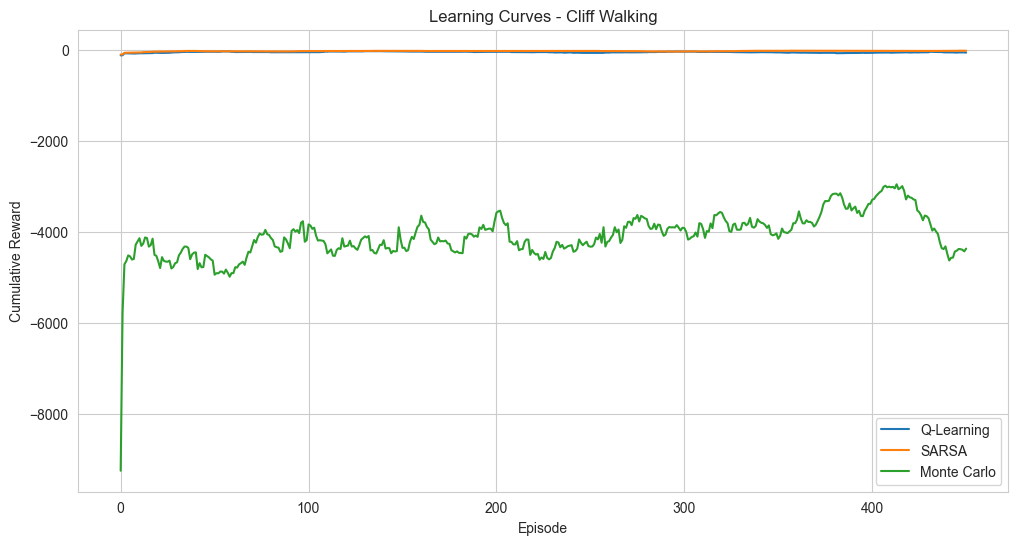

In [39]:
plt.figure(figsize=(12,6))

plt.plot(moving_average(rewards_q), label="Q-Learning")
plt.plot(moving_average(rewards_s), label="SARSA")
plt.plot(moving_average(rewards_mc), label="Monte Carlo")

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Learning Curves - Cliff Walking")
plt.legend()
plt.grid(True)
plt.show()

What you should see:

- Q-learning learns fast but risky path
- SARSA learns safer path
- Monte Carlo learns slower

**Cell 8 — Visualize Learned Policies**

In [42]:
print("Q-Learning Policy")
print_policy(derive_policy(Q_q))

print("\nSARSA Policy")
print_policy(derive_policy(Q_s))

print("\nMonte Carlo Policy")
print_policy(derive_policy(Q_mc))

Q-Learning Policy

Learned policy:
↓ → → → → ↓ ↑ → → → → ↓
← → ↓ ↓ → → ↓ → → ↓ ↓ ↓
→ → → → → → → → → → → ↓
S C C C C C C C C C C G

SARSA Policy

Learned policy:
→ → → → → → → → → → → ↓
→ → → ↑ → ↑ ↑ ↑ ← → → ↓
→ ↑ ↑ ↑ ↑ → ↑ ↑ ↑ ↑ → ↓
S C C C C C C C C C C G

Monte Carlo Policy

Learned policy:
→ → → → → → → → → → → ↓
↑ ↑ ↑ ↑ ← ↑ ↑ ↑ → ↑ ↑ ↓
↑ ↓ ← ← ← ← → ← ↓ ← → ↓
S C C C C C C C C C C G


**Cell 9 — Experiment with Different ε Values**

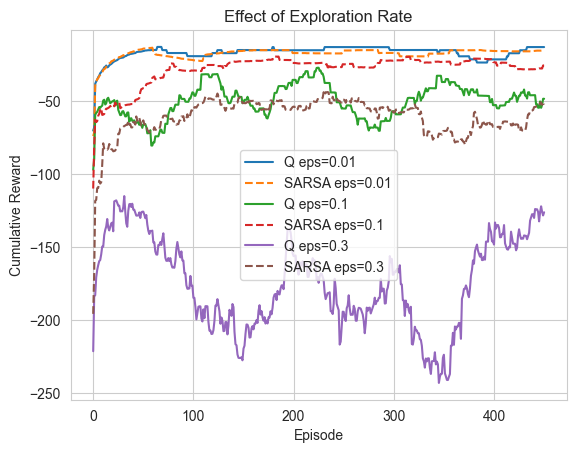

In [44]:
epsilons = [0.01, 0.1, 0.3]

for eps in epsilons:
    Q_q, rewards_q = run_q_learning(env, episodes, alpha, gamma, eps)
    Q_s, rewards_s = run_sarsa(env, episodes, alpha, gamma, eps)

    plt.plot(moving_average(rewards_q), label=f"Q eps={eps}")
    plt.plot(moving_average(rewards_s), linestyle="--", label=f"SARSA eps={eps}")

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Effect of Exploration Rate")
plt.legend()
plt.grid(True)
plt.show()

Key Concepts

| Method      | Type          | Learns                   | Behavior           |
| ----------- | ------------- | ------------------------ | ------------------ |
| Q-Learning  | Off-policy    | Optimal greedy policy    | Risky (near cliff) |
| SARSA       | On-policy     | Policy actually followed | Safer path         |
| Monte Carlo | Episode-based | True returns             | Slow learning      |


- Q-learning: "What is the best possible future?"
- SARSA: "What will I actually do next?"
- Monte Carlo: "How did the whole episode turn out?"